# Intraday Trading Strategy Backtesting

In [1]:
# Download and extracting data from google drive
!pip install -q gdown

import gdown
import pandas as pd
import os
import glob
import zipfile

# link for drive
# https://drive.google.com/file/d/1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B/view?usp=share_link
file_id = "1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B"
zip_path = "archive-2.zip"

# Download ZIP and extract it
print("Downloading archive-2.zip from shared Google Drive link...")
gdown.download(id=file_id, output=zip_path, quiet=False)

extract_path = "/content/archive-2"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
all_csv_files = glob.glob(os.path.join(extract_path, "**", "*.csv"), recursive=True)

print(f" Found {len(all_csv_files)} CSV files. Starting import...")

dataframes = {}  # For individual stocks
nifty = {}       # For Nifty indices

for file in all_csv_files:
    try:
        filename = os.path.basename(file)
        # Determine if it's a Nifty index file
        if "NIFTY" in filename:
            # Extract the index name (e.g., "NIFTY 50", "NIFTY BANK")
            index_name = filename.split('_')[0]
            df = pd.read_csv(file)
            nifty[index_name] = df
            print(f" Successfully loaded Nifty index: {filename}")
        else:
            # Extract ticker for individual stocks (same as before)
            ticker = filename.split('_')[0]
            df = pd.read_csv(file)
            dataframes[ticker] = df
            print(f" Successfully loaded stock: {filename}")
    except Exception as e:
        print(f" Failed to process {filename}. Error: {e}")

print("\n--- All files processed. ---")

Downloading...
From (original): https://drive.google.com/uc?id=1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B
From (redirected): https://drive.google.com/uc?id=1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B&confirm=t&uuid=3b5e2bb5-809c-4351-a4d4-90cc6a6ac8ac
To: /content/archive-2.zip
100%|██████████| 87.1M/87.1M [00:02<00:00, 42.8MB/s]


Extraction complete.
 Found 103 CSV files. Starting import...
 Successfully loaded stock: ADANIPOWER_15minute.csv
 Successfully loaded stock: ULTRACEMCO_15minute.csv
 Successfully loaded stock: INDHOTEL_15minute.csv
 Successfully loaded stock: HINDUNILVR_15minute.csv
 Successfully loaded stock: BEL_15minute.csv
 Successfully loaded stock: EICHERMOT_15minute.csv
 Successfully loaded stock: BAJAJFINSV_15minute.csv
 Successfully loaded stock: TATACONSUM_15minute.csv
 Successfully loaded stock: KOTAKBANK_15minute.csv
 Successfully loaded stock: IRFC_15minute.csv
 Successfully loaded stock: DRREDDY_15minute.csv
 Successfully loaded stock: NESTLEIND_15minute.csv
 Successfully loaded stock: HEROMOTOCO_15minute.csv
 Successfully loaded stock: MOTHERSON_15minute.csv
 Successfully loaded stock: DIVISLAB_15minute.csv
 Successfully loaded stock: HAL_15minute.csv
 Successfully loaded stock: PNB_15minute.csv
 Successfully loaded stock: NAUKRI_15minute.csv
 Successfully loaded stock: SIEMENS_15minute

In [2]:
import pandas as pd
import numpy as np

class Indicators:
    """
    A collection of static methods to calculate common financial technical indicators
    and add them as columns to a pandas DataFrame. Assumes the DataFrame index is a
    DatetimeIndex for time-based calculations.
    """

    @staticmethod
    def _ema(values: np.ndarray, period: int) -> np.ndarray:
        # Helper function for EMA
        n = len(values)
        ema = np.full(n, np.nan, dtype=float)
        if n < period or period <= 0:
            return ema
        seed = np.mean(values[:period])
        ema[period - 1] = seed
        alpha = 2.0 / (period + 1.0)
        for i in range(period, n):
            if np.isnan(values[i]):
                ema[i] = np.nan
                continue
            last_ema = ema[i - 1]
            if np.isnan(last_ema):
                valid_slice = values[i-period+1:i+1]
                if not np.isnan(valid_slice).all():
                     last_ema = np.nanmean(valid_slice)
                else:
                    continue
            ema[i] = (values[i] - last_ema) * alpha + last_ema
        return ema

    @staticmethod
    def add_rsi(df: pd.DataFrame, period: int = 14, price_col: str = "close", out_col: str = "rsi") -> pd.DataFrame:
        prices = df[price_col].to_numpy(dtype=float)
        n = len(prices)
        rsi = np.full(n, np.nan, dtype=float)
        if n > period:
            deltas = np.diff(prices)
            gains = np.clip(deltas, a_min=0.0, a_max=None)
            losses = np.clip(-deltas, a_min=0.0, a_max=None)
            avg_gain = np.full(n, np.nan, dtype=float)
            avg_loss = np.full(n, np.nan, dtype=float)
            avg_gain[period] = np.mean(gains[:period])
            avg_loss[period] = np.mean(losses[:period])
            for i in range(period + 1, n):
                avg_gain[i] = (avg_gain[i-1] * (period - 1) + gains[i-1]) / period
                avg_loss[i] = (avg_loss[i-1] * (period - 1) + losses[i-1]) / period
            rs = np.divide(avg_gain, avg_loss, out=np.full(n, np.nan), where=avg_loss!=0)
            rsi = 100 - (100 / (1 + rs))
        df[out_col] = rsi
        return df

    @staticmethod
    def add_macd(df: pd.DataFrame, fast: int = 12, slow: int = 26, signal: int = 9, price_col: str = "close", macd_col: str = "macd", signal_col: str = "macd_signal", hist_col: str = "macd_hist") -> pd.DataFrame:
        prices = df[price_col].to_numpy(dtype=float)
        ema_fast = Indicators._ema(prices, fast)
        ema_slow = Indicators._ema(prices, slow)
        macd = ema_fast - ema_slow
        signal_line = Indicators._ema(macd, signal)
        hist = macd - signal_line
        df[macd_col] = macd
        df[signal_col] = signal_line
        df[hist_col] = hist
        return df

    @staticmethod
    def add_ema(df: pd.DataFrame, period: int = 20, price_col: str = "close", out_col: str = None) -> pd.DataFrame:
        if out_col is None: out_col = f"ema_{period}"
        prices = df[price_col].to_numpy(dtype=float)
        df[out_col] = Indicators._ema(prices, period)
        return df

    @staticmethod
    def add_vwap(df: pd.DataFrame, high_col: str = "high", low_col: str = "low", close_col: str = "close", volume_col: str = "volume", out_col: str = "vwap") -> pd.DataFrame:
        if not isinstance(df.index, pd.DatetimeIndex): raise TypeError("DataFrame index must be a DatetimeIndex.")
        typical_price = (df[high_col] + df[low_col] + df[close_col]) / 3
        pv = typical_price * df[volume_col]
        cumulative_pv = pv.groupby(pv.index.date).cumsum()
        cumulative_vol = df[volume_col].groupby(df[volume_col].index.date).cumsum()
        df[out_col] = cumulative_pv / cumulative_vol
        df[out_col] = df[out_col].fillna(method='ffill')
        return df

    @staticmethod
    def add_atr(df: pd.DataFrame, period: int = 14, high_col: str = "high", low_col: str = "low", close_col: str = "close", out_col: str = "atr") -> pd.DataFrame:
        h_minus_l = df[high_col] - df[low_col]
        h_minus_pc = abs(df[high_col] - df[close_col].shift(1))
        l_minus_pc = abs(df[low_col] - df[close_col].shift(1))
        tr_df = pd.concat([h_minus_l, h_minus_pc, l_minus_pc], axis=1)
        true_range = tr_df.max(axis=1, skipna=False)
        df[out_col] = Indicators._ema(true_range.to_numpy(dtype=float), period)
        return df

    @staticmethod
    def add_adx(df: pd.DataFrame, period: int = 14, high_col: str = "high", low_col: str = "low", close_col: str = "close", adx_col: str = "adx", pdi_col: str = "pdi", ndi_col: str = "ndi") -> pd.DataFrame:
        """Calculates the Average Directional Index (ADX)."""
        high = df[high_col]
        low = df[low_col]
        close = df[close_col]

        up_move = high.diff()
        down_move = -low.diff()

        plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
        minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

        h_minus_l = high - low
        h_minus_pc = abs(high - close.shift(1))
        l_minus_pc = abs(low - close.shift(1))
        tr = pd.concat([h_minus_l, h_minus_pc, l_minus_pc], axis=1).max(axis=1, skipna=False)

        atr = Indicators._ema(tr.to_numpy(dtype=float), period)
        pdi = 100 * (Indicators._ema(plus_dm, period) / atr)
        ndi = 100 * (Indicators._ema(minus_dm, period) / atr)

        dx_values = 100 * (abs(pdi - ndi) / (pdi + ndi))
        adx = Indicators._ema(dx_values, period)

        df[pdi_col] = pdi
        df[ndi_col] = ndi
        df[adx_col] = adx
        return df

    @staticmethod
    def add_cci(df: pd.DataFrame, period: int = 20, high_col: str = "high", low_col: str = "low", close_col: str = "close", out_col: str = "cci") -> pd.DataFrame:
        """Calculates the Commodity Channel Index (CCI)."""
        tp = (df[high_col] + df[low_col] + df[close_col]) / 3
        sma_tp = tp.rolling(window=period).mean()
        mean_dev = tp.rolling(window=period).apply(lambda x: np.mean(np.abs(x - x.mean())))
        df[out_col] = (tp - sma_tp) / (0.015 * mean_dev)
        return df

    @staticmethod
    def add_roc(df: pd.DataFrame, period: int = 12, price_col: str = "close", out_col: str = "roc") -> pd.DataFrame:
        """Calculates the Rate of Change (ROC)."""
        df[out_col] = df[price_col].pct_change(periods=period) * 100
        return df

    @staticmethod
    def add_bb_width(df: pd.DataFrame, period: int = 20, std_dev: int = 2, price_col: str = "close", out_col: str = "bb_width") -> pd.DataFrame:
        """Calculates Bollinger Band Width."""
        middle_band = df[price_col].rolling(window=period).mean()
        std = df[price_col].rolling(window=period).std()
        upper_band = middle_band + (std * std_dev)
        lower_band = middle_band - (std * std_dev)
        df[out_col] = (upper_band - lower_band) / middle_band
        return df

    @staticmethod
    def add_hv(df: pd.DataFrame, period: int = 20, annual_periods: int = 252 * 25, price_col: str = "close", out_col: str = "hv") -> pd.DataFrame:
        """Calculates Historical Volatility (annualized). 25 = 15-min candles in a day."""
        log_returns = np.log(df[price_col] / df[price_col].shift(1))
        df[out_col] = log_returns.rolling(window=period).std() * np.sqrt(annual_periods)
        return df

    @staticmethod
    def add_vol_volatility(df: pd.DataFrame, period: int = 20, volume_col: str = "volume", out_col: str = "vol_volatility") -> pd.DataFrame:
        """Calculates the volatility (std dev) of volume."""
        df[out_col] = df[volume_col].rolling(window=period).std()
        return df

    @staticmethod
    def add_volume_ratio(df: pd.DataFrame, period: int = 20, volume_col: str = "volume", out_col: str = "vol_ratio") -> pd.DataFrame:
        """Calculates Current Volume / N-Day Average Volume."""
        avg_vol = df[volume_col].rolling(window=period).mean()
        df[out_col] = df[volume_col] / avg_vol
        return df

    @staticmethod
    def add_turnover(df: pd.DataFrame, close_col: str = "close", volume_col: str = "volume", out_col: str = "turnover") -> pd.DataFrame:
        """Calculates Turnover (Price * Volume)."""
        df[out_col] = df[close_col] * df[volume_col]
        return df

In [ ]:
import pandas as pd
from datetime import time
from tqdm.notebook import tqdm


strategy_dataframes = {}

print("Preparing dataframes with ALL indicators (from june 2023 onwards)")


for ticker, df in tqdm(dataframes.items(), desc="Processing Stocks"):
    if df.empty:
        continue

    df_processed = df.copy()


    date_column_name = 'date'
    df_processed[date_column_name] = pd.to_datetime(df_processed[date_column_name])

    # Filter data to start from june 2023
    df_processed = df_processed[df_processed[date_column_name] >= '2023-06-01']


    if df_processed.empty:
        continue

    # Set the date column as the index
    df_processed.set_index(date_column_name, inplace=True)

    # Calculating Indicators
    df_processed = Indicators.add_atr(df_processed, period=14)
    df_processed['atr_percent'] = (df_processed['atr'] / df_processed['close']) * 100
    df_processed = Indicators.add_rsi(df_processed, period=14)
    df_processed = Indicators.add_vwap(df_processed)
    df_processed = Indicators.add_adx(df_processed, period=14)
    df_processed = Indicators.add_cci(df_processed, period=20)
    df_processed = Indicators.add_roc(df_processed, period=12)
    df_processed = Indicators.add_bb_width(df_processed, period=20)
    df_processed = Indicators.add_hv(df_processed, period=20)
    df_processed = Indicators.add_vol_volatility(df_processed, period=20)
    df_processed = Indicators.add_volume_ratio(df_processed, period=20)
    df_processed = Indicators.add_turnover(df_processed)

    #Store the final dataframe
    strategy_dataframes[ticker] = df_processed

print(f"\n All {len(strategy_dataframes)} dataframes have been filtered and added with indicators.")

Preparing dataframes with ALL indicators (from june 2023 onwards)


Processing Stocks:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_4120/2876084585.py:84: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipykernel_4120/2876084585.py:84: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipykernel_4120/2876084585.py:84: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipykernel_4120/2876084585.py:84: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipykernel_4120/2876084585.py:84: FutureWarning: Series.fillna with 'method' is deprecated and will raise in

In [ ]:
import pandas as pd
import numpy as np

def Stock_Selections(date: str, dataframes_dict: dict, num_stocks: int = 8) -> list:
    """
    Selects the top N stocks based on a weighted multi-factor score of
    Momentum, Volatility, and Liquidity for a given date.
    Normalizes individual indicators and then the composite scores.
    Uses the previous trading day's data for selection.
    """
    target_date = pd.to_datetime(date)

    # Find the previous trading day present in the data
    previous_trading_day = None
    # Iterate through a sample of dataframes to find a common previous trading day
    # This assumes that most dataframes will have similar trading days
    # I used this idea to make the code easier assuming data is complete, most stocks will have a common trading day.
    for df in list(dataframes_dict.values())[:10]:
        if not df.empty:
            previous_days_in_data = df.index[df.index < target_date].sort_values(ascending=False)
            if not previous_days_in_data.empty:
                previous_trading_day = previous_days_in_data[0]
                break

    if previous_trading_day is None:
        print(f"Warning: No previous trading day found before {date} in the data.")
        return []

    target_date_str = previous_trading_day.strftime('%Y-%m-%d')


    stock_scores_data = []

    indicator_data = []

    for ticker, df in dataframes_dict.items():
        try:
            if target_date_str not in df.index:
                continue

            day_data = df.loc[target_date_str]
            if day_data.empty:
                continue

            #using the last candle of the day for indicator values
            last_candle = day_data.iloc[-1]

            # Collect indicator values for normalization
            indicator_values = {
                'ticker': ticker,
                'rsi': last_candle.get('rsi'),
                'adx': last_candle.get('adx'),
                'cci': last_candle.get('cci'),
                'roc': last_candle.get('roc'),
                'vwap_signal': (last_candle.get('close') - last_candle.get('vwap')) / last_candle.get('vwap') if last_candle.get('vwap') else np.nan,
                'atr_percent': last_candle.get('atr_percent'),
                'bb_width': last_candle.get('bb_width'),
                'hv': last_candle.get('hv'),
                'day_range': (day_data['high'].max() - day_data['low'].min()) / last_candle.get('close') if last_candle.get('close') else np.nan,
                'vol_volatility': last_candle.get('vol_volatility'),
                'vol_ratio': last_candle.get('vol_ratio'),
                'turnover': last_candle.get('turnover')
            }
            indicator_data.append(indicator_values)

        except KeyError:
            continue
        except ZeroDivisionError:
            continue


    if not indicator_data:
        return []


    # Convert indicator data to DataFrame for normalization
    indicator_df = pd.DataFrame(indicator_data)


    # all indicators we used are positive indicators
    positive_indicators = ['rsi', 'adx', 'cci', 'roc', 'vwap_signal', 'atr_percent', 'bb_width', 'hv', 'day_range', 'vol_volatility', 'vol_ratio', 'turnover']
    negative_indicators = []

    # 3. Normalize individual indicators to a 0-1 scale
    def indicator_scaler(series, is_positive):
        min_val, max_val = series.min(), series.max()
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
             # Return mid-point if no variation or all NaNs
            return pd.Series(0.5, index=series.index) if is_positive else pd.Series(0.5, index=series.index)
        scaled_series = (series - min_val) / (max_val - min_val)
        return scaled_series if is_positive else (1 - scaled_series) # Invert for negative indicators but we don't have negative indicators in our model, this is general code


    for col in positive_indicators:
         if col in indicator_df.columns:
            indicator_df[f'{col}_norm'] = indicator_scaler(indicator_df[col], is_positive=True)


    # Calculating Raw Scores for Each Factor
    for index, row in indicator_df.iterrows():

        # Define weightage of each
        momentum_norm = row.get('rsi_norm', 0.5) * 0.35 + \
                        row.get('adx_norm', 0.5) * 0.20 + \
                        row.get('cci_norm', 0.5) * 0.10 + \
                        row.get('roc_norm', 0.5) * 0.10 + \
                        row.get('vwap_signal_norm', 0.5) * 0.25

        volatility_norm = row.get('atr_percent_norm', 0.5) * 0.35 + \
                          row.get('bb_width_norm', 0.5) * 0.20 + \
                          row.get('hv_norm', 0.5) * 0.15 + \
                          row.get('day_range_norm', 0.5) * 0.15 + \
                          row.get('vol_volatility_norm', 0.5) * 0.15

        liquidity_norm = row.get('vol_ratio_norm', 0.5) * 0.5 + \
                         row.get('turnover_norm', 0.5) * 0.5

        # Add scores to list if they are all valid numbers (based on normalized indicators)
        # If any normalized indicator is NaN, the raw score will be NaN if not handled.
        # By using .get(col, 0.5) and weighting, we avoid NaNs here unless all are missing.
        stock_scores_data.append({
            'ticker': row['ticker'],
            'momentum_raw': momentum_norm,
            'volatility_raw': volatility_norm,
            'liquidity_raw': liquidity_norm
        })


    if not stock_scores_data:
        return []


    scores_df = pd.DataFrame(stock_scores_data)

    #Normalize the raw composite scores to a scale from 0-100
    def min_max_scaler_100(series):
        min_val, max_val = series.min(), series.max()
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
            return pd.Series(50.0, index=series.index)
        return (series - min_val) / (max_val - min_val) * 100

    scores_df['momentum_norm'] = min_max_scaler_100(scores_df['momentum_raw'])
    scores_df['volatility_norm'] = min_max_scaler_100(scores_df['volatility_raw'])
    scores_df['liquidity_norm'] = min_max_scaler_100(scores_df['liquidity_raw'])


    # Calculate the Final Weighted Score
    scores_df['final_score'] = (
        0.6 * scores_df['momentum_norm'] +
        0.3 * scores_df['volatility_norm'] +
        0.1 * scores_df['liquidity_norm']
    )

    # Sort by the final score and return the top N (by default it is 8) stock tickers
    top_stocks = scores_df.sort_values(by='final_score', ascending=False).head(num_stocks)

    return top_stocks['ticker'].tolist()

In [ ]:
# Test the Stock_Selections function for a specific date
test_date_selection = '2024-12-20'
#

selected_stocks_for_date = Stock_Selections(
    date=test_date_selection,
    dataframes_dict=strategy_dataframes,
    num_stocks=8
)

print(f"Top stocks selected for {test_date_selection}:")
print(selected_stocks_for_date)

In [ ]:
import pandas as pd
from datetime import time
import numpy as np


# Main loop - 1
def run_capital_based_strategy(date: str, all_data: dict, initial_portfolio: float) -> dict:
    """
    Runs an intraday strategy for a single day using a capital-based allocation,
    where a percentage of the initial daily capital is allocated to each selected stock,
    and this per-stock allocation compounds throughout the day.
    Includes ATR-based Stop Loss and Take Profit.
    """
    top_stocks = Stock_Selections(date=date, dataframes_dict=all_data, num_stocks=8)
    if not top_stocks:
        return {'trades': [], 'net_pnl_rs': 0}


    # Allocating roughlyu 10% of the initial daily capital to each selected stock for trading that particular stofck
    capital_per_stock_initial = initial_portfolio * 0.125
    # Initialize a dictionary to track the compounding capital for each stock
    capital_per_stock_current = {ticker: capital_per_stock_initial for ticker in top_stocks}

    completed_trades = []

    # Initialize state to track position, quantity, and exit levels for each stock
    portfolio_state = {ticker: {'position': 'none', 'entry_price': 0, 'entry_time': None, 'quantity': 0, 'stop_loss': np.nan, 'take_profit': np.nan} for ticker in top_stocks}

    # Get the day's trading timeline
    date_str = pd.to_datetime(date).strftime('%Y-%m-%d')
    try:
        # Ensure the first stock has data for the target date
        if top_stocks[0] not in all_data or all_data[top_stocks[0]].loc[date_str].empty:
             return {'trades': [], 'net_pnl_rs': 0}
        trading_timeline = all_data[top_stocks[0]].loc[date_str].index
    except KeyError:
        return {'trades': [], 'net_pnl_rs': 0} # Return only net_pnl_rs for compounding


    # Tiime
    force_close_time = time(15, 0)
    entry_start_time = time(9, 15)
    # We tested with starting later that 9:15 to check for some diff strategies but didn't work


    # Define ATR multipliers for Stop Loss and Take Profit
    atr_stop_loss_multiplier = 1.0
    atr_take_profit_multiplier = 4.5


    # Main Time Loop
    for timestamp in trading_timeline:
        for ticker in top_stocks:

            if timestamp not in all_data[ticker].index or capital_per_stock_current[ticker] <= 0:
                continue

            row = all_data[ticker].loc[timestamp]
            state = portfolio_state[ticker]
            current_price = row['close']
            current_atr = row.get('atr')


            # If a position is open, check for exits or force close
            if state['position'] != 'none':
                pnl_rs = 0
                exit_reason = None
                exit_price = current_price # Default exit price

                # Check for Stop Loss
                if state['position'] == 'long' and current_price <= state['stop_loss']:
                    exit_reason = 'Stop Loss'
                    exit_price = state['stop_loss'] # Exiting at the stop loss price
                elif state['position'] == 'short' and current_price >= state['stop_loss']:
                    exit_reason = 'Stop Loss'
                    exit_price = state['stop_loss'] # Exit taken at the stop loss price

                # Check for Take Profit
                if exit_reason is None:
                     if state['position'] == 'long' and current_price >= state['take_profit']:
                         exit_reason = 'Take Profit'
                         exit_price = state['take_profit'] # Exiting at the take profit price
                     elif state['position'] == 'short' and current_price <= state['take_profit']:
                         exit_reason = 'Take Profit'
                         exit_price = state['take_profit'] # Exiting at the take profit price

                # Check for original signal exit
                if exit_reason is None:
                     if state['position'] == 'long' and (row['close'] < row['vwap'] or row['rsi'] >= 70):
                         exit_reason = 'Signal'
                         exit_price = current_price
                     elif state['position'] == 'short' and (row['close'] > row['vwap'] or row['rsi'] <= 30):
                         exit_reason = 'Signal'
                         exit_price = current_price

                # Force Close at end of day
                if exit_reason is None and timestamp.time() >= force_close_time:
                    exit_reason = 'Force Close'
                    exit_price = current_price


                if exit_reason:
                    if state['position'] == 'long':
                        pnl_rs = (exit_price - state['entry_price']) * state['quantity']
                    else:
                        pnl_rs = (state['entry_price'] - exit_price) * state['quantity']

                    # Update the allocated capital for this stock with the trades profin n loss
                    capital_per_stock_current[ticker] += pnl_rs

                    completed_trades.append({
                        'ticker': ticker, 'type': state['position'], 'entry_time': state['entry_time'],
                        'exit_time': timestamp, 'entry_price': state['entry_price'], 'exit_price': exit_price,
                        'quantity': state['quantity'], 'pnl_rs': pnl_rs, 'exit_reason': exit_reason,
                        'capital_after_trade': capital_per_stock_current[ticker] # Log capital after trade
                    })
                    # Reset state for this stock
                    portfolio_state[ticker] = {'position': 'none', 'entry_price': 0, 'entry_time': None, 'quantity': 0, 'stop_loss': np.nan, 'take_profit': np.nan}

            # If no position is open check for entries
            else:
                # Only check for new trades on or after the entry start time ---
                if timestamp.time() >= entry_start_time and not np.isnan(current_atr):
                    # Calculate quantity based on the current allocated capital for this stock
                    quantity = int(capital_per_stock_current[ticker] / current_price)

                    if quantity > 0:
                        # Calculate ATR-based Stop Loss and Take Profit levels
                        if row['close'] > row['vwap'] and row['rsi'] < 70:
                            stop_loss = current_price - (atr_stop_loss_multiplier * current_atr)
                            take_profit = current_price + (atr_take_profit_multiplier * current_atr)
                            portfolio_state[ticker] = {'position': 'long', 'entry_price': current_price, 'entry_time': timestamp, 'quantity': quantity, 'stop_loss': stop_loss, 'take_profit': take_profit}

                        elif row['close'] < row['vwap'] and row['rsi'] > 30:
                            stop_loss = current_price + (atr_stop_loss_multiplier * current_atr)
                            take_profit = current_price - (atr_take_profit_multiplier * current_atr)
                            portfolio_state[ticker] = {'position': 'short', 'entry_price': current_price, 'entry_time': timestamp, 'quantity': quantity, 'stop_loss': stop_loss, 'take_profit': take_profit}


    # Calculate net PnL for the day by summing up the *changes* in allocated capital for each stock
    net_pnl_for_day = sum(capital_per_stock_current[ticker] - capital_per_stock_initial for ticker in top_stocks)


    return {'trades': completed_trades, 'net_pnl_rs': net_pnl_for_day} # Return net_pnl_rs for compounding

In [ ]:
# Setup for the Day Test
initial_portfolio_value = 100000
test_date = '2024-12-20'

# Run the Capital-Based Strategy
daily_results = run_capital_based_strategy(
    date=test_date,
    all_data=strategy_dataframes,
    initial_portfolio=initial_portfolio_value
)

# Display the Detailed Results
daily_trades = daily_results['trades']

if daily_trades:
    trades_df = pd.DataFrame(daily_trades)

    # better visualizations
    trades_df = trades_df[['ticker', 'type', 'entry_time', 'exit_time', 'entry_price', 'exit_price', 'quantity', 'pnl_rs', 'exit_reason']]
    print(f"Found {len(trades_df)} trades on {test_date}:")
    display(trades_df.round(2))

else:
    print(f"No trades were executed on {test_date}.")


# Calculate final_portfolio for the single day test
final_portfolio = initial_portfolio_value + daily_results['net_pnl_rs']
net_pnl = daily_results['net_pnl_rs']
net_return_percent = (net_pnl / initial_portfolio_value) * 100

print("\n" + "-"*45)
print(f" Daily Portfolio Summary for {test_date}")
print("-"*45)
print(f"Initial Portfolio: \t₹ {initial_portfolio_value:,.2f}")
print(f"Final Portfolio: \t₹ {final_portfolio:,.2f}")
print(f"Net Profit/Loss: \t₹ {net_pnl:,.2f}")
print(f" Net Return: \t\t{net_return_percent:.2f}%")
print("-"*45)

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
# Using progress barr because it takes time to get backtest results

def run_full_backtest(start_date: str, end_date: str, initial_capital: float, all_data: dict) -> tuple:
    """
    Runs the capital-based strategy over a date range with a compounding portfolio.
    """
    # Create a range of business days for the backtest period
    date_range = pd.bdate_range(start=start_date, end=end_date)

    # Initialize tracking variables
    portfolio_value = initial_capital
    all_trades = []
    daily_portfolio_log = [{'date': pd.to_datetime(start_date) - pd.Timedelta(days=1), 'portfolio_value': initial_capital}]

    print(f"Running full backtest from {start_date} to {end_date}...")
    for day in tqdm(date_range, desc="Backtesting Progress"):
        # The initial portfolio for today is the final value from yesterday
        todays_initial_portfolio = portfolio_value

        # Run the strategy for one day
        daily_results = run_capital_based_strategy(
            date=day.strftime('%Y-%m-%d'),
            all_data=all_data,
            initial_portfolio=todays_initial_portfolio
        )

        # Update the main portfolio value by adding the day's net PnL
        portfolio_value += daily_results['net_pnl_rs']

        # Log the portfolio value at the end of the day
        daily_portfolio_log.append({'date': day, 'portfolio_value': portfolio_value})

        # Collect all trades
        if daily_results['trades']:
            all_trades.extend(daily_results['trades'])

    print(f"\n Backtest complete.")

    # Return both the list of all trades and the daily portfolio history
    trades_df = pd.DataFrame(all_trades)
    portfolio_log_df = pd.DataFrame(daily_portfolio_log).set_index('date')

    return trades_df, portfolio_log_df

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def analyze_full_performance(trades_df: pd.DataFrame, portfolio_log_df: pd.DataFrame, initial_capital: float, all_data: dict):
    """
    Calculates and prints a detailed performance summary for the full backtest,
    and displays the equity curve, the portfolio drawdown curve, and daily returns.
    Includes additional trade and return metrics.
    """
    if portfolio_log_df.empty:
        print("No trading days to analyze.")
        return

  # Calculate portfolio metric.
    trading_portfolio_log = portfolio_log_df.copy()


    final_value = trading_portfolio_log['portfolio_value'].iloc[-1]
    total_return_percent = (final_value / initial_capital - 1) * 100

    #calculating daily returns for volatility and Sharpe Ratio
    daily_returns = trading_portfolio_log['portfolio_value'].pct_change().dropna()

    # calculate Annualized Portfolio Volatility
    annualized_volatility = daily_returns.std() * np.sqrt(252) * 100 if daily_returns.std() != 0 and len(daily_returns) > 1 else 0


    # Annualized Sharpe Ratio (assuming 252 trading days)
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 and len(daily_returns) > 1 else 0

    # Calculate Sortino Ratio
    downside_returns = daily_returns[daily_returns < 0]
    # Calculate downside deviation
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    # Calculate Sortino Ratio (assuming risk-free rate is 0)
    sortino_ratio = (daily_returns.mean() / downside_deviation) * np.sqrt(252) if downside_deviation != 0 and len(daily_returns) > 1 else 0


    # calculate Max Drawdown and Drawdown Series
    running_max = trading_portfolio_log['portfolio_value'].cummax()
    drawdown = (trading_portfolio_log['portfolio_value'] - running_max) / running_max
    max_drawdown_percent = abs(drawdown.min()) * 100 if not drawdown.empty else 0


    # Calculate Trade Metrics
    total_trades = len(trades_df)
    win_rate = (trades_df['pnl_rs'] > 0).sum() / total_trades * 100 if total_trades > 0 else 0

    # Calculate long and short trades and their win percentages
    long_trades_df = trades_df[trades_df['type'] == 'long']
    short_trades_df = trades_df[trades_df['type'] == 'short']

    num_long_trades = len(long_trades_df)
    num_short_trades = len(short_trades_df)

    long_win_rate = (long_trades_df['pnl_rs'] > 0).sum() / num_long_trades * 100 if num_long_trades > 0 else 0
    short_win_rate = (short_trades_df['pnl_rs'] > 0).sum() / num_short_trades * 100 if num_short_trades > 0 else 0

    # Calculate Average Daily Return
    average_daily_return_percent = daily_returns.mean() * 100 if not daily_returns.empty else 0

    # Calculate Average Return per Trade
    average_pnl_per_trade = trades_df['pnl_rs'].mean() if total_trades > 0 else 0

    # Calculate Average Holding Time per Trade
    if total_trades > 0:
        # Ensure entry_time and exit_time are datetime objects
        trades_df['entry_time'] = pd.to_datetime(trades_df['entry_time'])
        trades_df['exit_time'] = pd.to_datetime(trades_df['exit_time'])
        holding_times = trades_df['exit_time'] - trades_df['entry_time']
        average_holding_time = holding_times.mean()
    else:
        average_holding_time = pd.Timedelta(seconds=0) # Or np.nan

    # Print the Performance Report
    print("\nFull Backtest Performance Report")
    print("\n")
    print(f"Total Return: \t\t{total_return_percent:.2f}%")
    print(f"Max Drawdown: \t\t-{max_drawdown_percent:.2f}%")
    print(f"Annualized Volatility: \t{annualized_volatility:.2f}%")
    print(f"Sharpe Ratio: \t\t{sharpe_ratio:.2f}")
    print(f"Sortino Ratio: \t\t{sortino_ratio:.2f}")
    print("----------------------------------------")
    print(f"Total Trades: \t\t{total_trades}")
    print(f"Win Rate (Overall): \t{win_rate:.2f}%")
    print(f"Number of Long Trades: \t{num_long_trades}")
    print(f"Win Rate (Long): \t{long_win_rate:.2f}%")
    print(f"Number of Short Trades: {num_short_trades}")
    print(f"Win Rate (Short): \t{short_win_rate:.2f}%")
    print(f"Avg Daily Return: \t{average_daily_return_percent:.2f}%")
    print(f"Avg PnL per Trade: \t₹ {average_pnl_per_trade:,.2f}")
    print(f"Avg Holding Time: \t{average_holding_time}")


    print("\n")
    print(f"Initial Portfolio: \t₹ {initial_capital:,.2f}")
    print(f"Final Portfolio: \t₹ {final_value:,.2f}")

    #plot Equity Curve
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(14, 7))
    trading_portfolio_log.iloc[1:]['portfolio_value'].plot(title='Portfolio Equity Curve', color='navy', linewidth=2)
    plt.ylabel("Portfolio Value (₹)")
    plt.xlabel("Date")
    plt.grid(True)
    plt.show()

In [ ]:
def draw_down_graph_backtesting(trades_df: pd.DataFrame, portfolio_log_df: pd.DataFrame, initial_capital: float, all_data: dict):
    """
    Calculates and prints a detailed performance summary for the full backtest,
    and displays the equity curve, the portfolio drawdown curve, and daily returns.
    """
    if portfolio_log_df.empty:
        print("No trading days to analyze.")
        return



    trading_portfolio_log = portfolio_log_df.copy()


    final_value = trading_portfolio_log['portfolio_value'].iloc[-1]
    total_return_percent = (final_value / initial_capital - 1) * 100

    daily_returns = trading_portfolio_log['portfolio_value'].pct_change().dropna()



    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 and len(daily_returns) > 1 else 0


    running_max = trading_portfolio_log['portfolio_value'].cummax()
    drawdown = (trading_portfolio_log['portfolio_value'] - running_max) / running_max
    max_drawdown_percent = abs(drawdown.min()) * 100 if not drawdown.empty else 0



    plt.figure(figsize=(14, 7))

    drawdown.plot(title='Portfolio Drawdown', color='red', linewidth=2)
    plt.ylabel("Drawdown (%)")
    plt.xlabel("Date")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def daily_returns_graph(trades_df: pd.DataFrame, portfolio_log_df: pd.DataFrame, initial_capital: float, all_data: dict):
    """
    Calculates and prints a detailed performance summary for the full backtest,
    and displays the equity curve, the portfolio drawdown curve, and daily returns.
    """
    if portfolio_log_df.empty:
        print("No trading days to analyze.")
        return

    trading_portfolio_log = portfolio_log_df.copy()


    final_value = trading_portfolio_log['portfolio_value'].iloc[-1]
    total_return_percent = (final_value / initial_capital - 1) * 100
    daily_returns = trading_portfolio_log['portfolio_value'].pct_change().dropna()





    plt.figure(figsize=(14, 7))
    (daily_returns * 100).plot(title='Daily Portfolio Returns (%)', color='green', linewidth=1)
    plt.ylabel("Daily Return (%)")
    plt.xlabel("Date")
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.grid(True)
    plt.show()

In [ ]:
# Define Your Backtest Period and Capital
START_DATE = '2024-07-01'
END_DATE = '2025-06-30'
INITIAL_CAPITAL = 100000



# Run the full backtest to get the results
trades_df, portfolio_log_df = run_full_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    initial_capital=INITIAL_CAPITAL,
    all_data=strategy_dataframes
)

# Analyze the performance and display the report and chart
if not portfolio_log_df.empty:
    analyze_full_performance(trades_df, portfolio_log_df, INITIAL_CAPITAL, all_data=strategy_dataframes)

In [ ]:
START_DATE = '2024-07-01'
END_DATE = '2025-06-30'
INITIAL_CAPITAL = 100000

trades_df, portfolio_log_df = run_full_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    initial_capital=INITIAL_CAPITAL,
    all_data=strategy_dataframes
)

if not portfolio_log_df.empty:
    draw_down_graph_backtesting(trades_df, portfolio_log_df, INITIAL_CAPITAL, all_data=strategy_dataframes)

In [ ]:
START_DATE = '2024-07-01'
END_DATE = '2025-06-30'
INITIAL_CAPITAL = 100000

trades_df, portfolio_log_df = run_full_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    initial_capital=INITIAL_CAPITAL,
    all_data=strategy_dataframes
)

if not portfolio_log_df.empty:
    daily_returns_graph(trades_df, portfolio_log_df, INITIAL_CAPITAL, all_data=strategy_dataframes)

In [ ]:
# Ensure the necessary dataframes exist
if 'portfolio_log_df' not in locals() or portfolio_log_df.empty:
    print("Portfolio log data not available. Please run the backtest first.")
elif 'nifty' not in locals() or 'NIFTY 50' not in nifty or 'NIFTY 100' not in nifty:
    print("Nifty 50 or Nifty 100 data not available. Please ensure data loading was successful.")
else:
    # Get the portfolio value series, excluding the initial capital entry for
    portfolio_values = portfolio_log_df.iloc[1:]['portfolio_value']

    # Get the Nifty 50 and Nifty 100 dataframes
    nifty_50_df = nifty['NIFTY 50'].copy()
    nifty_100_df = nifty['NIFTY 100'].copy()


    date_column_name = 'date'
    nifty_50_df[date_column_name] = pd.to_datetime(nifty_50_df[date_column_name])
    nifty_50_df.set_index(date_column_name, inplace=True)

    nifty_100_df[date_column_name] = pd.to_datetime(nifty_100_df[date_column_name])
    nifty_100_df.set_index(date_column_name, inplace=True)

    # Filter Nifty data to match the backtest period
    start_date = portfolio_values.index[0] # Start from the first trading day of the backtest
    end_date = portfolio_values.index[-1]   # End at the last trading day of the backtest

    nifty_50_benchmark = nifty_50_df.loc[start_date:end_date]['close']
    nifty_100_benchmark = nifty_100_df.loc[start_date:end_date]['close']

    # Normalize the benchmarks to start at the same value as the initial portfolio capital
    nifty_50_start_price = nifty_50_benchmark.iloc[0] if not nifty_50_benchmark.empty else None
    nifty_100_start_price = nifty_100_benchmark.iloc[0] if not nifty_100_benchmark.empty else None

    if nifty_50_start_price is not None and nifty_100_start_price is not None:
        initial_benchmark_value = INITIAL_CAPITAL if 'INITIAL_CAPITAL' in locals() else 100000

        nifty_50_normalized = (nifty_50_benchmark / nifty_50_start_price) * initial_benchmark_value
        nifty_100_normalized = (nifty_100_benchmark / nifty_100_start_price) * initial_benchmark_value

        # Plotting
        plt.style.use('seaborn-v0_8-darkgrid')
        plt.figure(figsize=(14, 7))

        plt.plot(portfolio_values.index, portfolio_values, label='Portfolio Equity Curve', color='navy', linewidth=2)
        plt.plot(nifty_50_normalized.index, nifty_50_normalized, label='NIFTY 50 Benchmark', color='orange', linestyle='--')
        plt.plot(nifty_100_normalized.index, nifty_100_normalized, label='NIFTY 100 Benchmark', color='green', linestyle='--')

        plt.title('Portfolio Performance vs. Nifty Benchmarks')
        plt.xlabel('Date')
        plt.ylabel("Value (₹)")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Could not normalize benchmark data. Ensure Nifty data is available for the backtest period.")

In [ ]:
# Analyze trade exit reasons
if 'trades_df' in locals() and not trades_df.empty:
    print("Trade Exit Reason Analysis:")
    exit_reason_counts = trades_df['exit_reason'].value_counts()
    display(exit_reason_counts)


else:
    print("Trade data not available. Please run the backtest first.")

In [ ]:
# Download and extracting data from google drive
!pip install -q gdown

import gdown
import pandas as pd
import os
import glob
import zipfile

# link for drive
# https://drive.google.com/file/d/1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B/view?usp=share_link
file_id = "1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B"
zip_path = "archive-2.zip"

# Download ZIP and extract it
print("Downloading archive-2.zip from shared Google Drive link...")
gdown.download(id=file_id, output=zip_path, quiet=False)

extract_path = "/content/archive-2"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
all_csv_files = glob.glob(os.path.join(extract_path, "**", "*.csv"), recursive=True)

print(f" Found {len(all_csv_files)} CSV files. Starting import...")

dataframes = {}  # For individual stocks
nifty = {}       # For Nifty indices

for file in all_csv_files:
    try:
        filename = os.path.basename(file)
        # Determine if it's a Nifty index file
        if "NIFTY" in filename:
            # Extract the index name (e.g., "NIFTY 50", "NIFTY BANK")
            index_name = filename.split('_')[0]
            df = pd.read_csv(file)
            nifty[index_name] = df
            print(f" Successfully loaded Nifty index: {filename}")
        else:
            # Extract ticker for individual stocks (same as before)
            ticker = filename.split('_')[0]
            df = pd.read_csv(file)
            dataframes[ticker] = df
            print(f" Successfully loaded stock: {filename}")
    except Exception as e:
        print(f" Failed to process {filename}. Error: {e}")

print("\n--- All files processed. ---")

⬇️ Downloading archive-2.zip from shared Google Drive link...


Downloading...
From (original): https://drive.google.com/uc?id=1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B
From (redirected): https://drive.google.com/uc?id=1FkS-dK20zNBFdJ3s-IWlH_ReJGnp0J6B&confirm=t&uuid=01d656a9-c4d4-4a65-8119-090b688ec37a
To: /content/archive-2.zip
100%|██████████| 87.1M/87.1M [00:01<00:00, 44.1MB/s]


✅ Extraction complete.
📂 Found 103 CSV files. Starting import...
✅ Successfully loaded stock: BOSCHLTD_15minute.csv
✅ Successfully loaded stock: HCLTECH_15minute.csv
✅ Successfully loaded stock: ABB_15minute.csv
✅ Successfully loaded stock: BEL_15minute.csv
✅ Successfully loaded stock: BHARTIARTL_15minute.csv
✅ Successfully loaded stock: APOLLOHOSP_15minute.csv
✅ Successfully loaded stock: BAJAJHFL_15minute.csv
✅ Successfully loaded stock: DMART_15minute.csv
✅ Successfully loaded stock: SHREECEM_15minute.csv
✅ Successfully loaded stock: HDFCBANK_15minute.csv
✅ Successfully loaded stock: HEROMOTOCO_15minute.csv
✅ Successfully loaded stock: SHRIRAMFIN_15minute.csv
✅ Successfully loaded stock: VEDL_15minute.csv
✅ Successfully loaded stock: BAJAJ-AUTO_15minute.csv
✅ Successfully loaded stock: TORNTPHARM_15minute.csv
✅ Successfully loaded stock: BAJFINANCE_15minute.csv
✅ Successfully loaded stock: GAIL_15minute.csv
✅ Successfully loaded stock: RECLTD_15minute.csv
✅ Successfully loaded stock

In [ ]:
import pandas as pd
import numpy as np

class Indicators:
    """
    A collection of static methods to calculate common financial technical indicators
    and add them as columns to a pandas DataFrame. Assumes the DataFrame index is a
    DatetimeIndex for time-based calculations.
    """

    @staticmethod
    def _ema(values: np.ndarray, period: int) -> np.ndarray:
        # Helper function for EMA
        n = len(values)
        ema = np.full(n, np.nan, dtype=float)
        if n < period or period <= 0:
            return ema
        seed = np.mean(values[:period])
        ema[period - 1] = seed
        alpha = 2.0 / (period + 1.0)
        for i in range(period, n):
            if np.isnan(values[i]):
                ema[i] = np.nan
                continue
            last_ema = ema[i - 1]
            if np.isnan(last_ema):
                valid_slice = values[i-period+1:i+1]
                if not np.isnan(valid_slice).all():
                     last_ema = np.nanmean(valid_slice)
                else:
                    continue
            ema[i] = (values[i] - last_ema) * alpha + last_ema
        return ema

    @staticmethod
    def add_rsi(df: pd.DataFrame, period: int = 14, price_col: str = "close", out_col: str = "rsi") -> pd.DataFrame:
        prices = df[price_col].to_numpy(dtype=float)
        n = len(prices)
        rsi = np.full(n, np.nan, dtype=float)
        if n > period:
            deltas = np.diff(prices)
            gains = np.clip(deltas, a_min=0.0, a_max=None)
            losses = np.clip(-deltas, a_min=0.0, a_max=None)
            avg_gain = np.full(n, np.nan, dtype=float)
            avg_loss = np.full(n, np.nan, dtype=float)
            avg_gain[period] = np.mean(gains[:period])
            avg_loss[period] = np.mean(losses[:period])
            for i in range(period + 1, n):
                avg_gain[i] = (avg_gain[i-1] * (period - 1) + gains[i-1]) / period
                avg_loss[i] = (avg_loss[i-1] * (period - 1) + losses[i-1]) / period
            rs = np.divide(avg_gain, avg_loss, out=np.full(n, np.nan), where=avg_loss!=0)
            rsi = 100 - (100 / (1 + rs))
        df[out_col] = rsi
        return df

    @staticmethod
    def add_macd(df: pd.DataFrame, fast: int = 12, slow: int = 26, signal: int = 9, price_col: str = "close", macd_col: str = "macd", signal_col: str = "macd_signal", hist_col: str = "macd_hist") -> pd.DataFrame:
        prices = df[price_col].to_numpy(dtype=float)
        ema_fast = Indicators._ema(prices, fast)
        ema_slow = Indicators._ema(prices, slow)
        macd = ema_fast - ema_slow
        signal_line = Indicators._ema(macd, signal)
        hist = macd - signal_line
        df[macd_col] = macd
        df[signal_col] = signal_line
        df[hist_col] = hist
        return df

    @staticmethod
    def add_ema(df: pd.DataFrame, period: int = 20, price_col: str = "close", out_col: str = None) -> pd.DataFrame:
        if out_col is None: out_col = f"ema_{period}"
        prices = df[price_col].to_numpy(dtype=float)
        df[out_col] = Indicators._ema(prices, period)
        return df

    @staticmethod
    def add_vwap(df: pd.DataFrame, high_col: str = "high", low_col: str = "low", close_col: str = "close", volume_col: str = "volume", out_col: str = "vwap") -> pd.DataFrame:
        if not isinstance(df.index, pd.DatetimeIndex): raise TypeError("DataFrame index must be a DatetimeIndex.")
        typical_price = (df[high_col] + df[low_col] + df[close_col]) / 3
        pv = typical_price * df[volume_col]
        cumulative_pv = pv.groupby(pv.index.date).cumsum()
        cumulative_vol = df[volume_col].groupby(df[volume_col].index.date).cumsum()
        df[out_col] = cumulative_pv / cumulative_vol
        df[out_col] = df[out_col].fillna(method='ffill')
        return df

    @staticmethod
    def add_atr(df: pd.DataFrame, period: int = 14, high_col: str = "high", low_col: str = "low", close_col: str = "close", out_col: str = "atr") -> pd.DataFrame:
        h_minus_l = df[high_col] - df[low_col]
        h_minus_pc = abs(df[high_col] - df[close_col].shift(1))
        l_minus_pc = abs(df[low_col] - df[close_col].shift(1))
        tr_df = pd.concat([h_minus_l, h_minus_pc, l_minus_pc], axis=1)
        true_range = tr_df.max(axis=1, skipna=False)
        df[out_col] = Indicators._ema(true_range.to_numpy(dtype=float), period)
        return df

    @staticmethod
    def add_adx(df: pd.DataFrame, period: int = 14, high_col: str = "high", low_col: str = "low", close_col: str = "close", adx_col: str = "adx", pdi_col: str = "pdi", ndi_col: str = "ndi") -> pd.DataFrame:
        """Calculates the Average Directional Index (ADX)."""
        high = df[high_col]
        low = df[low_col]
        close = df[close_col]

        up_move = high.diff()
        down_move = -low.diff()

        plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
        minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

        h_minus_l = high - low
        h_minus_pc = abs(high - close.shift(1))
        l_minus_pc = abs(low - close.shift(1))
        tr = pd.concat([h_minus_l, h_minus_pc, l_minus_pc], axis=1).max(axis=1, skipna=False)

        atr = Indicators._ema(tr.to_numpy(dtype=float), period)
        pdi = 100 * (Indicators._ema(plus_dm, period) / atr)
        ndi = 100 * (Indicators._ema(minus_dm, period) / atr)

        dx_values = 100 * (abs(pdi - ndi) / (pdi + ndi))
        adx = Indicators._ema(dx_values, period)

        df[pdi_col] = pdi
        df[ndi_col] = ndi
        df[adx_col] = adx
        return df

    @staticmethod
    def add_cci(df: pd.DataFrame, period: int = 20, high_col: str = "high", low_col: str = "low", close_col: str = "close", out_col: str = "cci") -> pd.DataFrame:
        """Calculates the Commodity Channel Index (CCI)."""
        tp = (df[high_col] + df[low_col] + df[close_col]) / 3
        sma_tp = tp.rolling(window=period).mean()
        mean_dev = tp.rolling(window=period).apply(lambda x: np.mean(np.abs(x - x.mean())))
        df[out_col] = (tp - sma_tp) / (0.015 * mean_dev)
        return df

    @staticmethod
    def add_roc(df: pd.DataFrame, period: int = 12, price_col: str = "close", out_col: str = "roc") -> pd.DataFrame:
        """Calculates the Rate of Change (ROC)."""
        df[out_col] = df[price_col].pct_change(periods=period) * 100
        return df

    @staticmethod
    def add_bb_width(df: pd.DataFrame, period: int = 20, std_dev: int = 2, price_col: str = "close", out_col: str = "bb_width") -> pd.DataFrame:
        """Calculates Bollinger Band Width."""
        middle_band = df[price_col].rolling(window=period).mean()
        std = df[price_col].rolling(window=period).std()
        upper_band = middle_band + (std * std_dev)
        lower_band = middle_band - (std * std_dev)
        df[out_col] = (upper_band - lower_band) / middle_band
        return df

    @staticmethod
    def add_hv(df: pd.DataFrame, period: int = 20, annual_periods: int = 252 * 25, price_col: str = "close", out_col: str = "hv") -> pd.DataFrame:
        """Calculates Historical Volatility (annualized). 25 = 15-min candles in a day."""
        log_returns = np.log(df[price_col] / df[price_col].shift(1))
        df[out_col] = log_returns.rolling(window=period).std() * np.sqrt(annual_periods)
        return df

    @staticmethod
    def add_vol_volatility(df: pd.DataFrame, period: int = 20, volume_col: str = "volume", out_col: str = "vol_volatility") -> pd.DataFrame:
        """Calculates the volatility (std dev) of volume."""
        df[out_col] = df[volume_col].rolling(window=period).std()
        return df

    @staticmethod
    def add_volume_ratio(df: pd.DataFrame, period: int = 20, volume_col: str = "volume", out_col: str = "vol_ratio") -> pd.DataFrame:
        """Calculates Current Volume / N-Day Average Volume."""
        avg_vol = df[volume_col].rolling(window=period).mean()
        df[out_col] = df[volume_col] / avg_vol
        return df

    @staticmethod
    def add_turnover(df: pd.DataFrame, close_col: str = "close", volume_col: str = "volume", out_col: str = "turnover") -> pd.DataFrame:
        """Calculates Turnover (Price * Volume)."""
        df[out_col] = df[close_col] * df[volume_col]
        return df

In [ ]:
import pandas as pd
from datetime import time
from tqdm.notebook import tqdm


strategy_dataframes = {}

print("Preparing dataframes with ALL indicators (from june 2023 onwards)")


for ticker, df in tqdm(dataframes.items(), desc="Processing Stocks"):
    if df.empty:
        continue

    df_processed = df.copy()


    date_column_name = 'date'
    df_processed[date_column_name] = pd.to_datetime(df_processed[date_column_name])

    # Filter data to start from june 2023
    df_processed = df_processed[df_processed[date_column_name] >= '2023-06-01']


    if df_processed.empty:
        continue

    # Set the date column as the index
    df_processed.set_index(date_column_name, inplace=True)

    # Calculating Indicators
    df_processed = Indicators.add_atr(df_processed, period=14)
    df_processed['atr_percent'] = (df_processed['atr'] / df_processed['close']) * 100
    df_processed = Indicators.add_rsi(df_processed, period=14)
    df_processed = Indicators.add_vwap(df_processed)
    df_processed = Indicators.add_adx(df_processed, period=14)
    df_processed = Indicators.add_cci(df_processed, period=20)
    df_processed = Indicators.add_roc(df_processed, period=12)
    df_processed = Indicators.add_bb_width(df_processed, period=20)
    df_processed = Indicators.add_hv(df_processed, period=20)
    df_processed = Indicators.add_vol_volatility(df_processed, period=20)
    df_processed = Indicators.add_volume_ratio(df_processed, period=20)
    df_processed = Indicators.add_turnover(df_processed)

    #Store the final dataframe
    strategy_dataframes[ticker] = df_processed

print(f"\n All {len(strategy_dataframes)} dataframes have been filtered and added with indicators.")


Preparing dataframes with ALL indicators (from june 2023 onwards)...


Processing Stocks:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipython-input-1120986990.py:85: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipython-input-1120986990.py:85: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipython-input-1120986990.py:85: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipython-input-1120986990.py:85: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[out_col] = df[out_col].fillna(method='ffill')
/tmp/ipython-input-1120986990.py:85: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a fu


✅ All 100 dataframes have been filtered and enriched with indicators.


In [ ]:

import pandas as pd
import numpy as np

def Stock_Selections(date: str, dataframes_dict: dict, num_stocks: int = 8) -> list:
    """
    Selects the top N stocks based on a weighted multi-factor score of
    Momentum, Volatility, and Liquidity for a given date.
    Normalizes individual indicators and then the composite scores.
    Uses the previous trading day's data for selection.
    """
    target_date = pd.to_datetime(date)

    # Find the previous trading day present in the data
    previous_trading_day = None
    # Iterate through a sample of dataframes to find a common previous trading day
    # This assumes that most dataframes will have similar trading days
    # I used this idea to make the code easier assuming data is complete, most stocks will have a common trading day.
    for df in list(dataframes_dict.values())[:10]:
        if not df.empty:
            previous_days_in_data = df.index[df.index < target_date].sort_values(ascending=False)
            if not previous_days_in_data.empty:
                previous_trading_day = previous_days_in_data[0]
                break

    if previous_trading_day is None:
        print(f"Warning: No previous trading day found before {date} in the data.")
        return []

    target_date_str = previous_trading_day.strftime('%Y-%m-%d')


    stock_scores_data = []

    indicator_data = []

    for ticker, df in dataframes_dict.items():
        try:
            if target_date_str not in df.index:
                continue

            day_data = df.loc[target_date_str]
            if day_data.empty:
                continue

            #using the last candle of the day for indicator values
            last_candle = day_data.iloc[-1]

            # Collect indicator values for normalization
            indicator_values = {
                'ticker': ticker,
                'rsi': last_candle.get('rsi'),
                'adx': last_candle.get('adx'),
                'cci': last_candle.get('cci'),
                'roc': last_candle.get('roc'),
                'vwap_signal': (last_candle.get('close') - last_candle.get('vwap')) / last_candle.get('vwap') if last_candle.get('vwap') else np.nan,
                'atr_percent': last_candle.get('atr_percent'),
                'bb_width': last_candle.get('bb_width'),
                'hv': last_candle.get('hv'),
                'day_range': (day_data['high'].max() - day_data['low'].min()) / last_candle.get('close') if last_candle.get('close') else np.nan,
                'vol_volatility': last_candle.get('vol_volatility'),
                'vol_ratio': last_candle.get('vol_ratio'),
                'turnover': last_candle.get('turnover')
            }
            indicator_data.append(indicator_values)

        except KeyError:
            continue
        except ZeroDivisionError:
            continue


    if not indicator_data:
        return []


    # Convert indicator data to DataFrame for normalization
    indicator_df = pd.DataFrame(indicator_data)


    # all indicators we used are positive indicators
    positive_indicators = ['rsi', 'adx', 'cci', 'roc', 'vwap_signal', 'atr_percent', 'bb_width', 'hv', 'day_range', 'vol_volatility', 'vol_ratio', 'turnover']
    negative_indicators = []

    # 3. Normalize individual indicators to a 0-1 scale
    def indicator_scaler(series, is_positive):
        min_val, max_val = series.min(), series.max()
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
             # Return mid-point if no variation or all NaNs
            return pd.Series(0.5, index=series.index) if is_positive else pd.Series(0.5, index=series.index)
        scaled_series = (series - min_val) / (max_val - min_val)
        return scaled_series if is_positive else (1 - scaled_series) # Invert for negative indicators but we don't have negative indicators in our model, this is general code


    for col in positive_indicators:
         if col in indicator_df.columns:
            indicator_df[f'{col}_norm'] = indicator_scaler(indicator_df[col], is_positive=True)


    # Calculating Raw Scores for Each Factor
    for index, row in indicator_df.iterrows():

        # Define weightage of each
        momentum_norm = row.get('rsi_norm', 0.5) * 0.35 + \
                        row.get('adx_norm', 0.5) * 0.20 + \
                        row.get('cci_norm', 0.5) * 0.10 + \
                        row.get('roc_norm', 0.5) * 0.10 + \
                        row.get('vwap_signal_norm', 0.5) * 0.25

        volatility_norm = row.get('atr_percent_norm', 0.5) * 0.35 + \
                          row.get('bb_width_norm', 0.5) * 0.20 + \
                          row.get('hv_norm', 0.5) * 0.15 + \
                          row.get('day_range_norm', 0.5) * 0.15 + \
                          row.get('vol_volatility_norm', 0.5) * 0.15

        liquidity_norm = row.get('vol_ratio_norm', 0.5) * 0.5 + \
                         row.get('turnover_norm', 0.5) * 0.5

        # Add scores to list if they are all valid numbers (based on normalized indicators)
        # If any normalized indicator is NaN, the raw score will be NaN if not handled.
        # By using .get(col, 0.5) and weighting, we avoid NaNs here unless all are missing.
        stock_scores_data.append({
            'ticker': row['ticker'],
            'momentum_raw': momentum_norm,
            'volatility_raw': volatility_norm,
            'liquidity_raw': liquidity_norm
        })


    if not stock_scores_data:
        return []


    scores_df = pd.DataFrame(stock_scores_data)

    #Normalize the raw composite scores to a scale from 0-100
    def min_max_scaler_100(series):
        min_val, max_val = series.min(), series.max()
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
            return pd.Series(50.0, index=series.index)
        return (series - min_val) / (max_val - min_val) * 100

    scores_df['momentum_norm'] = min_max_scaler_100(scores_df['momentum_raw'])
    scores_df['volatility_norm'] = min_max_scaler_100(scores_df['volatility_raw'])
    scores_df['liquidity_norm'] = min_max_scaler_100(scores_df['liquidity_raw'])


    # Calculate the Final Weighted Score
    scores_df['final_score'] = (
        0.6 * scores_df['momentum_norm'] +
        0.3 * scores_df['volatility_norm'] +
        0.1 * scores_df['liquidity_norm']
    )

    # Sort by the final score and return the top N (by default it is 8) stock tickers
    top_stocks = scores_df.sort_values(by='final_score', ascending=False).head(num_stocks)

    return top_stocks['ticker'].tolist()

In [ ]:
# Test the Stock_Selections function for a specific date
test_date_selection = '2024-12-20'
#

selected_stocks_for_date = Stock_Selections(
    date=test_date_selection,
    dataframes_dict=strategy_dataframes,
    num_stocks=8
)

print(f"Top stocks selected for {test_date_selection}:")
print(selected_stocks_for_date)

Top stocks selected for 2024-12-20:
['BAJAJHLDNG', 'DRREDDY', 'IRFC', 'LODHA', 'ICICIGI', 'IOC', 'SUNPHARMA', 'APOLLOHOSP']


In [ ]:
import pandas as pd
from datetime import time
import numpy as np


# Main loop - 1
def run_capital_based_strategy(date: str, all_data: dict, initial_portfolio: float) -> dict:
    """
    Runs an intraday strategy for a single day using a capital-based allocation,
    where a percentage of the initial daily capital is allocated to each selected stock,
    and this per-stock allocation compounds throughout the day.
    Includes ATR-based Stop Loss and Take Profit.
    """
    top_stocks = Stock_Selections(date=date, dataframes_dict=all_data, num_stocks=8)
    if not top_stocks:
        return {'trades': [], 'net_pnl_rs': 0}


    # Allocating roughlyu 10% of the initial daily capital to each selected stock for trading that particular stofck
    capital_per_stock_initial = initial_portfolio * 0.125
    # Initialize a dictionary to track the compounding capital for each stock
    capital_per_stock_current = {ticker: capital_per_stock_initial for ticker in top_stocks}

    completed_trades = []

    # Initialize state to track position, quantity, and exit levels for each stock
    portfolio_state = {ticker: {'position': 'none', 'entry_price': 0, 'entry_time': None, 'quantity': 0, 'stop_loss': np.nan, 'take_profit': np.nan} for ticker in top_stocks}

    # Get the day's trading timeline
    date_str = pd.to_datetime(date).strftime('%Y-%m-%d')
    try:
        # Ensure the first stock has data for the target date
        if top_stocks[0] not in all_data or all_data[top_stocks[0]].loc[date_str].empty:
             return {'trades': [], 'net_pnl_rs': 0}
        trading_timeline = all_data[top_stocks[0]].loc[date_str].index
    except KeyError:
        return {'trades': [], 'net_pnl_rs': 0} # Return only net_pnl_rs for compounding


    # Tiime
    force_close_time = time(15, 0)
    entry_start_time = time(9, 15)
    # We tested with starting later that 9:15 to check for some diff strategies but didn't work


    # Define ATR multipliers for Stop Loss and Take Profit
    atr_stop_loss_multiplier = 1.0
    atr_take_profit_multiplier = 4.5


    # Main Time Loop
    for timestamp in trading_timeline:
        for ticker in top_stocks:

            if timestamp not in all_data[ticker].index or capital_per_stock_current[ticker] <= 0:
                continue

            row = all_data[ticker].loc[timestamp]
            state = portfolio_state[ticker]
            current_price = row['close']
            current_atr = row.get('atr')


            # If a position is open, check for exits or force close
            if state['position'] != 'none':
                pnl_rs = 0
                exit_reason = None
                exit_price = current_price # Default exit price

                # Check for Stop Loss
                if state['position'] == 'long' and current_price <= state['stop_loss']:
                    exit_reason = 'Stop Loss'
                    exit_price = state['stop_loss'] # Exiting at the stop loss price
                elif state['position'] == 'short' and current_price >= state['stop_loss']:
                    exit_reason = 'Stop Loss'
                    exit_price = state['stop_loss'] # Exit taken at the stop loss price

                # Check for Take Profit
                if exit_reason is None:
                     if state['position'] == 'long' and current_price >= state['take_profit']:
                         exit_reason = 'Take Profit'
                         exit_price = state['take_profit'] # Exiting at the take profit price
                     elif state['position'] == 'short' and current_price <= state['take_profit']:
                         exit_reason = 'Take Profit'
                         exit_price = state['take_profit'] # Exiting at the take profit price

                # Check for original signal exit
                if exit_reason is None:
                     if state['position'] == 'long' and (row['close'] < row['vwap'] or row['rsi'] >= 70):
                         exit_reason = 'Signal'
                         exit_price = current_price
                     elif state['position'] == 'short' and (row['close'] > row['vwap'] or row['rsi'] <= 30):
                         exit_reason = 'Signal'
                         exit_price = current_price

                # Force Close at end of day
                if exit_reason is None and timestamp.time() >= force_close_time:
                    exit_reason = 'Force Close'
                    exit_price = current_price


                if exit_reason:
                    if state['position'] == 'long':
                        pnl_rs = (exit_price - state['entry_price']) * state['quantity']
                    else:
                        pnl_rs = (state['entry_price'] - exit_price) * state['quantity']

                    # Update the allocated capital for this stock with the trades profin n loss
                    capital_per_stock_current[ticker] += pnl_rs

                    completed_trades.append({
                        'ticker': ticker, 'type': state['position'], 'entry_time': state['entry_time'],
                        'exit_time': timestamp, 'entry_price': state['entry_price'], 'exit_price': exit_price,
                        'quantity': state['quantity'], 'pnl_rs': pnl_rs, 'exit_reason': exit_reason,
                        'capital_after_trade': capital_per_stock_current[ticker] # Log capital after trade
                    })
                    # Reset state for this stock
                    portfolio_state[ticker] = {'position': 'none', 'entry_price': 0, 'entry_time': None, 'quantity': 0, 'stop_loss': np.nan, 'take_profit': np.nan}

            # If no position is open check for entries
            else:
                # Only check for new trades on or after the entry start time ---
                if timestamp.time() >= entry_start_time and not np.isnan(current_atr):
                    # Calculate quantity based on the current allocated capital for this stock
                    quantity = int(capital_per_stock_current[ticker] / current_price)

                    if quantity > 0:
                        # Calculate ATR-based Stop Loss and Take Profit levels
                        if row['close'] > row['vwap'] and row['rsi'] < 70:
                            stop_loss = current_price - (atr_stop_loss_multiplier * current_atr)
                            take_profit = current_price + (atr_take_profit_multiplier * current_atr)
                            portfolio_state[ticker] = {'position': 'long', 'entry_price': current_price, 'entry_time': timestamp, 'quantity': quantity, 'stop_loss': stop_loss, 'take_profit': take_profit}

                        elif row['close'] < row['vwap'] and row['rsi'] > 30:
                            stop_loss = current_price + (atr_stop_loss_multiplier * current_atr)
                            take_profit = current_price - (atr_take_profit_multiplier * current_atr)
                            portfolio_state[ticker] = {'position': 'short', 'entry_price': current_price, 'entry_time': timestamp, 'quantity': quantity, 'stop_loss': stop_loss, 'take_profit': take_profit}


    # Calculate net PnL for the day by summing up the *changes* in allocated capital for each stock
    net_pnl_for_day = sum(capital_per_stock_current[ticker] - capital_per_stock_initial for ticker in top_stocks)


    return {'trades': completed_trades, 'net_pnl_rs': net_pnl_for_day} # Return net_pnl_rs for compounding

In [ ]:
# Setup for the Day Test
initial_portfolio_value = 100000
test_date = '2024-12-20'

# Run the Capital-Based Strategy
daily_results = run_capital_based_strategy(
    date=test_date,
    all_data=strategy_dataframes,
    initial_portfolio=initial_portfolio_value
)

# Display the Detailed Results
daily_trades = daily_results['trades']

if daily_trades:
    trades_df = pd.DataFrame(daily_trades)

    # better visualizations
    trades_df = trades_df[['ticker', 'type', 'entry_time', 'exit_time', 'entry_price', 'exit_price', 'quantity', 'pnl_rs', 'exit_reason']]
    print(f"Found {len(trades_df)} trades on {test_date}:")
    display(trades_df.round(2))

else:
    print(f"No trades were executed on {test_date}.")


# Calculate final_portfolio for the single day test
final_portfolio = initial_portfolio_value + daily_results['net_pnl_rs']
net_pnl = daily_results['net_pnl_rs']
net_return_percent = (net_pnl / initial_portfolio_value) * 100

print("\n" + "-"*45)
print(f" Daily Portfolio Summary for {test_date}")
print("-"*45)
print(f"Initial Portfolio: \t₹ {initial_portfolio_value:,.2f}")
print(f"Final Portfolio: \t₹ {final_portfolio:,.2f}")
print(f"Net Profit/Loss: \t₹ {net_pnl:,.2f}")
print(f" Net Return: \t\t{net_return_percent:.2f}%")
print("-"*45)

Found 32 trades on 2024-12-20:


,ticker,type,entry_time,exit_time,entry_price,exit_price,quantity,pnl_rs,exit_reason
0,BAJAJHLDNG,short,2024-12-20 09:15:00,2024-12-20 09:30:00,11225.30,11256.90,1,-31.60,Signal
1,IRFC,short,2024-12-20 09:15:00,2024-12-20 09:30:00,153.09,153.83,81,-59.94,Signal
2,IOC,short,2024-12-20 09:15:00,2024-12-20 09:30:00,138.90,139.51,89,-54.58,Stop Loss
3,SUNPHARMA,short,2024-12-20 09:15:00,2024-12-20 09:30:00,1816.40,1822.00,6,-33.60,Signal
4,APOLLOHOSP,long,2024-12-20 09:15:00,2024-12-20 09:30:00,7302.75,7344.10,1,41.35,Signal
5,ICICIGI,long,2024-12-20 09:15:00,2024-12-20 10:00:00,1901.65,1899.35,6,-13.80,Signal
6,IOC,long,2024-12-20 09:45:00,2024-12-20 10:00:00,140.10,139.32,88,-68.64,Signal
7,ICICIGI,short,2024-12-20 10:15:00,2024-12-20 10:30:00,1895.40,1899.50,6,-24.60,Signal
8,IOC,short,2024-12-20 10:15:00,2024-12-20 10:30:00,139.79,140.55,88,-66.88,Signal
9,SUNPHARMA,short,2024-12-20 09:45:00,2024-12-20 10:30:00,1811.45,1816.05,6,-27.60,Signal



🗓️ Daily Portfolio Summary for 2024-12-20
Initial Portfolio: 	₹ 100,000.00
Final Portfolio: 	₹ 100,746.39
Net Profit/Loss: 	₹ 746.39
✅ Net Return: 		0.75%


In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
# Using progress barr because it takes time to get backtest results

def run_full_backtest(start_date: str, end_date: str, initial_capital: float, all_data: dict) -> tuple:
    """
    Runs the capital-based strategy over a date range with a compounding portfolio.
    """
    # Create a range of business days for the backtest period
    date_range = pd.bdate_range(start=start_date, end=end_date)

    # Initialize tracking variables
    portfolio_value = initial_capital
    all_trades = []
    daily_portfolio_log = [{'date': pd.to_datetime(start_date) - pd.Timedelta(days=1), 'portfolio_value': initial_capital}]

    print(f"Running full backtest from {start_date} to {end_date}...")
    for day in tqdm(date_range, desc="Backtesting Progress"):
        # The initial portfolio for today is the final value from yesterday
        todays_initial_portfolio = portfolio_value

        # Run the strategy for one day
        daily_results = run_capital_based_strategy(
            date=day.strftime('%Y-%m-%d'),
            all_data=all_data,
            initial_portfolio=todays_initial_portfolio
        )

        # Update the main portfolio value by adding the day's net PnL
        portfolio_value += daily_results['net_pnl_rs']

        # Log the portfolio value at the end of the day
        daily_portfolio_log.append({'date': day, 'portfolio_value': portfolio_value})

        # Collect all trades
        if daily_results['trades']:
            all_trades.extend(daily_results['trades'])

    print(f"\n Backtest complete.")

    # Return both the list of all trades and the daily portfolio history
    trades_df = pd.DataFrame(all_trades)
    portfolio_log_df = pd.DataFrame(daily_portfolio_log).set_index('date')

    return trades_df, portfolio_log_df

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def analyze_full_performance(trades_df: pd.DataFrame, portfolio_log_df: pd.DataFrame, initial_capital: float, all_data: dict):
    """
    Calculates and prints a detailed performance summary for the full backtest,
    and displays the equity curve, the portfolio drawdown curve, and daily returns.
    Includes additional trade and return metrics.
    """
    if portfolio_log_df.empty:
        print("No trading days to analyze.")
        return

  # Calculate portfolio metric.
    trading_portfolio_log = portfolio_log_df.copy()


    final_value = trading_portfolio_log['portfolio_value'].iloc[-1]
    total_return_percent = (final_value / initial_capital - 1) * 100

    #calculating daily returns for volatility and Sharpe Ratio
    daily_returns = trading_portfolio_log['portfolio_value'].pct_change().dropna()

    # calculate Annualized Portfolio Volatility
    annualized_volatility = daily_returns.std() * np.sqrt(252) * 100 if daily_returns.std() != 0 and len(daily_returns) > 1 else 0


    # Annualized Sharpe Ratio (assuming 252 trading days)
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 and len(daily_returns) > 1 else 0

    # Calculate Sortino Ratio
    downside_returns = daily_returns[daily_returns < 0]
    # Calculate downside deviation
    downside_deviation = downside_returns.std() if not downside_returns.empty else 0
    # Calculate Sortino Ratio (assuming risk-free rate is 0)
    sortino_ratio = (daily_returns.mean() / downside_deviation) * np.sqrt(252) if downside_deviation != 0 and len(daily_returns) > 1 else 0


    # calculate Max Drawdown and Drawdown Series
    running_max = trading_portfolio_log['portfolio_value'].cummax()
    drawdown = (trading_portfolio_log['portfolio_value'] - running_max) / running_max
    max_drawdown_percent = abs(drawdown.min()) * 100 if not drawdown.empty else 0


    # Calculate Trade Metrics
    total_trades = len(trades_df)
    win_rate = (trades_df['pnl_rs'] > 0).sum() / total_trades * 100 if total_trades > 0 else 0

    # Calculate long and short trades and their win percentages
    long_trades_df = trades_df[trades_df['type'] == 'long']
    short_trades_df = trades_df[trades_df['type'] == 'short']

    num_long_trades = len(long_trades_df)
    num_short_trades = len(short_trades_df)

    long_win_rate = (long_trades_df['pnl_rs'] > 0).sum() / num_long_trades * 100 if num_long_trades > 0 else 0
    short_win_rate = (short_trades_df['pnl_rs'] > 0).sum() / num_short_trades * 100 if num_short_trades > 0 else 0

    # Calculate Average Daily Return
    average_daily_return_percent = daily_returns.mean() * 100 if not daily_returns.empty else 0

    # Calculate Average Return per Trade
    average_pnl_per_trade = trades_df['pnl_rs'].mean() if total_trades > 0 else 0

    # Calculate Average Holding Time per Trade
    if total_trades > 0:
        # Ensure entry_time and exit_time are datetime objects
        trades_df['entry_time'] = pd.to_datetime(trades_df['entry_time'])
        trades_df['exit_time'] = pd.to_datetime(trades_df['exit_time'])
        holding_times = trades_df['exit_time'] - trades_df['entry_time']
        average_holding_time = holding_times.mean()
    else:
        average_holding_time = pd.Timedelta(seconds=0) # Or np.nan

    # Print the Performance Report
    print("\nFull Backtest Performance Report")
    print("\n")
    print(f"Total Return: \t\t{total_return_percent:.2f}%")
    print(f"Max Drawdown: \t\t-{max_drawdown_percent:.2f}%")
    print(f"Annualized Volatility: \t{annualized_volatility:.2f}%")
    print(f"Sharpe Ratio: \t\t{sharpe_ratio:.2f}")
    print(f"Sortino Ratio: \t\t{sortino_ratio:.2f}")
    print("----------------------------------------")
    print(f"Total Trades: \t\t{total_trades}")
    print(f"Win Rate (Overall): \t{win_rate:.2f}%")
    print(f"Number of Long Trades: \t{num_long_trades}")
    print(f"Win Rate (Long): \t{long_win_rate:.2f}%")
    print(f"Number of Short Trades: {num_short_trades}")
    print(f"Win Rate (Short): \t{short_win_rate:.2f}%")
    print(f"Avg Daily Return: \t{average_daily_return_percent:.2f}%")
    print(f"Avg PnL per Trade: \t₹ {average_pnl_per_trade:,.2f}")
    print(f"Avg Holding Time: \t{average_holding_time}")


    print("\n")
    print(f"Initial Portfolio: \t₹ {initial_capital:,.2f}")
    print(f"Final Portfolio: \t₹ {final_value:,.2f}")

    #plot Equity Curve
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(14, 7))
    trading_portfolio_log.iloc[1:]['portfolio_value'].plot(title='Portfolio Equity Curve', color='navy', linewidth=2)
    plt.ylabel("Portfolio Value (₹)")
    plt.xlabel("Date")
    plt.grid(True)
    plt.show()

    # # --- 6. Plot Drawdown Curve ---
    # plt.figure(figsize=(14, 7))
    # # Plot the drawdown as a percentage
    # drawdown.plot(title='Portfolio Drawdown', color='red', linewidth=2)
    # plt.ylabel("Drawdown (%)")
    # plt.xlabel("Date")
    # plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y))) # Format as percentage with 1 decimal place
    # plt.grid(True)
    # plt.show()

    # # --- 7. Plot Daily Returns ---
    # plt.figure(figsize=(14, 7))
    # # Plot daily returns as a percentage
    # (daily_returns * 100).plot(title='Daily Portfolio Returns (%)', color='green', linewidth=1)
    # plt.ylabel("Daily Return (%)")
    # plt.xlabel("Date")
    # plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0% for reference
    # plt.grid(True)
    # plt.show()

In [ ]:
def draw_down_graph_backtesting(trades_df: pd.DataFrame, portfolio_log_df: pd.DataFrame, initial_capital: float, all_data: dict):
    """
    Calculates and prints a detailed performance summary for the full backtest,
    and displays the equity curve, the portfolio drawdown curve, and daily returns.
    """
    if portfolio_log_df.empty:
        print("No trading days to analyze.")
        return



    trading_portfolio_log = portfolio_log_df.copy()


    final_value = trading_portfolio_log['portfolio_value'].iloc[-1]
    total_return_percent = (final_value / initial_capital - 1) * 100

    daily_returns = trading_portfolio_log['portfolio_value'].pct_change().dropna()



    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 and len(daily_returns) > 1 else 0


    running_max = trading_portfolio_log['portfolio_value'].cummax()
    drawdown = (trading_portfolio_log['portfolio_value'] - running_max) / running_max
    max_drawdown_percent = abs(drawdown.min()) * 100 if not drawdown.empty else 0



    plt.figure(figsize=(14, 7))

    drawdown.plot(title='Portfolio Drawdown', color='red', linewidth=2)
    plt.ylabel("Drawdown (%)")
    plt.xlabel("Date")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    plt.grid(True)
    plt.show()




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def daily_returns_graph(trades_df: pd.DataFrame, portfolio_log_df: pd.DataFrame, initial_capital: float, all_data: dict):
    """
    Calculates and prints a detailed performance summary for the full backtest,
    and displays the equity curve, the portfolio drawdown curve, and daily returns.
    """
    if portfolio_log_df.empty:
        print("No trading days to analyze.")
        return

    trading_portfolio_log = portfolio_log_df.copy()


    final_value = trading_portfolio_log['portfolio_value'].iloc[-1]
    total_return_percent = (final_value / initial_capital - 1) * 100
    daily_returns = trading_portfolio_log['portfolio_value'].pct_change().dropna()





    plt.figure(figsize=(14, 7))
    (daily_returns * 100).plot(title='Daily Portfolio Returns (%)', color='green', linewidth=1)
    plt.ylabel("Daily Return (%)")
    plt.xlabel("Date")
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.grid(True)
    plt.show()

Running full backtest from 2024-07-01 to 2025-06-30...


Backtesting Progress:   0%|          | 0/261 [00:00<?, ?it/s]


 Backtest complete.

--- Full Backtest Performance Report ---
Total Return: 		39.90%
Max Drawdown: 		-2.84%
Annualized Volatility: 	8.13%
Sharpe Ratio: 		4.03
Sortino Ratio: 		7.62
----------------------------------------
Total Trades: 		6800
Win Rate (Overall): 	35.66%
Number of Long Trades: 	3069
Win Rate (Long): 	36.62%
Number of Short Trades: 3731
Win Rate (Short): 	34.87%
Avg Daily Return: 	0.13%
Avg PnL per Trade: 	₹ 5.87
Avg Holding Time: 	0 days 01:15:55.852941176
Initial Portfolio: 	₹ 100,000.00
Final Portfolio: 	₹ 139,902.76


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


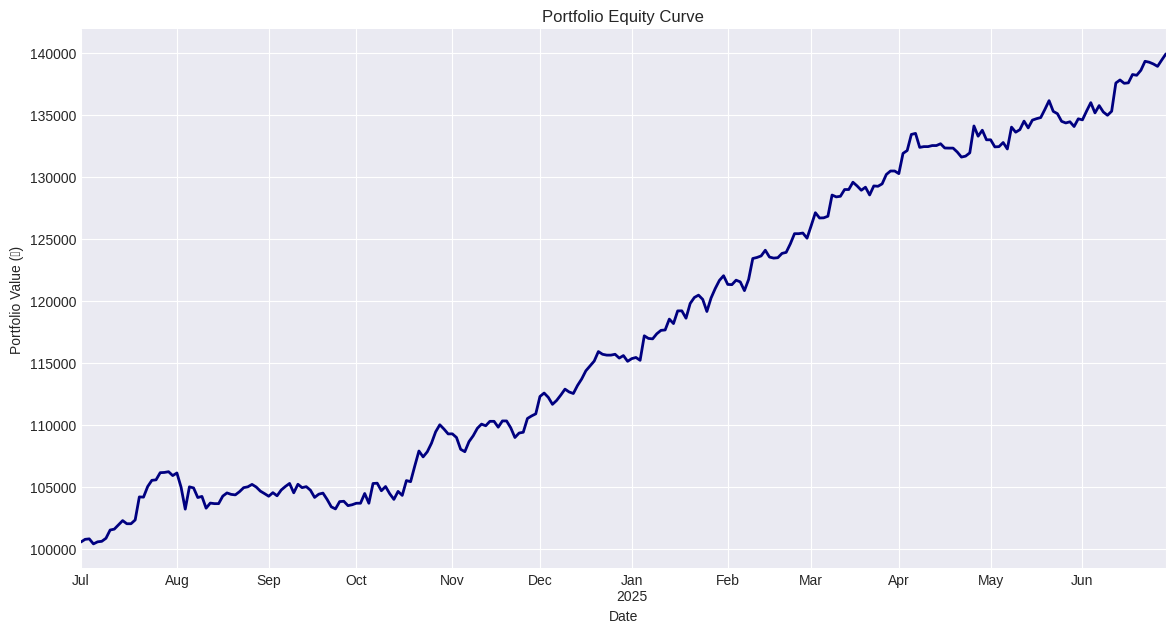

In [ ]:
# Define Your Backtest Period and Capital
START_DATE = '2024-07-01'
END_DATE = '2025-06-30'
INITIAL_CAPITAL = 100000



# Run the full backtest to get the results
trades_df, portfolio_log_df = run_full_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    initial_capital=INITIAL_CAPITAL,
    all_data=strategy_dataframes
)

# Analyze the performance and display the report and chart
if not portfolio_log_df.empty:
    analyze_full_performance(trades_df, portfolio_log_df, INITIAL_CAPITAL, all_data=strategy_dataframes)

Running full backtest from 2024-07-01 to 2025-06-30...


Backtesting Progress:   0%|          | 0/261 [00:00<?, ?it/s]


 Backtest complete.


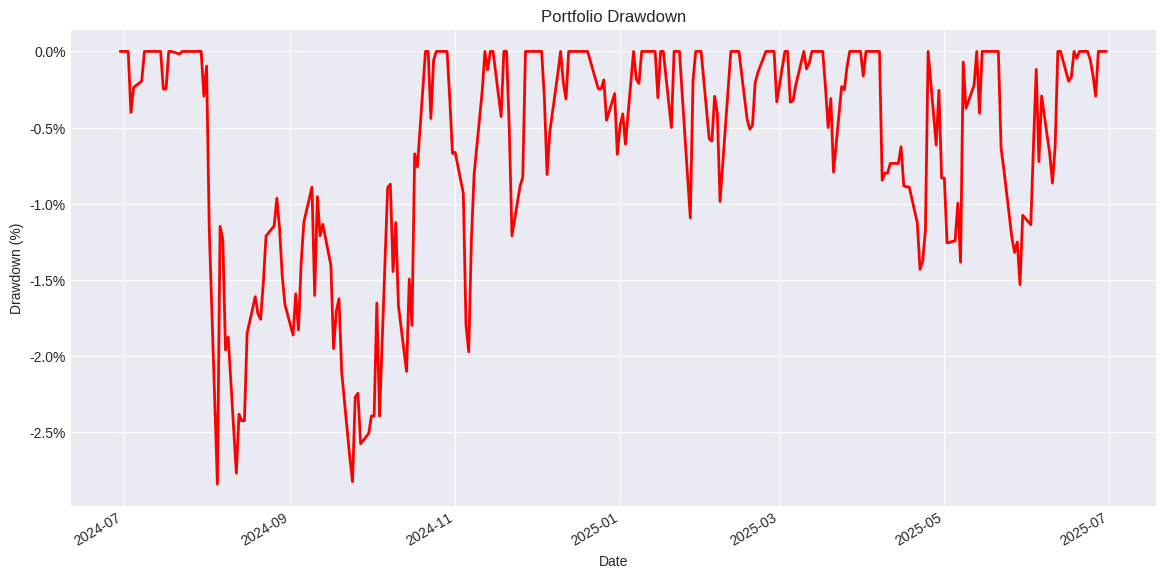

In [ ]:
START_DATE = '2024-07-01'
END_DATE = '2025-06-30'
INITIAL_CAPITAL = 100000

trades_df, portfolio_log_df = run_full_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    initial_capital=INITIAL_CAPITAL,
    all_data=strategy_dataframes
)

if not portfolio_log_df.empty:
    draw_down_graph_backtesting(trades_df, portfolio_log_df, INITIAL_CAPITAL, all_data=strategy_dataframes)

Running full backtest from 2024-07-01 to 2025-06-30...


Backtesting Progress:   0%|          | 0/261 [00:00<?, ?it/s]


 Backtest complete.


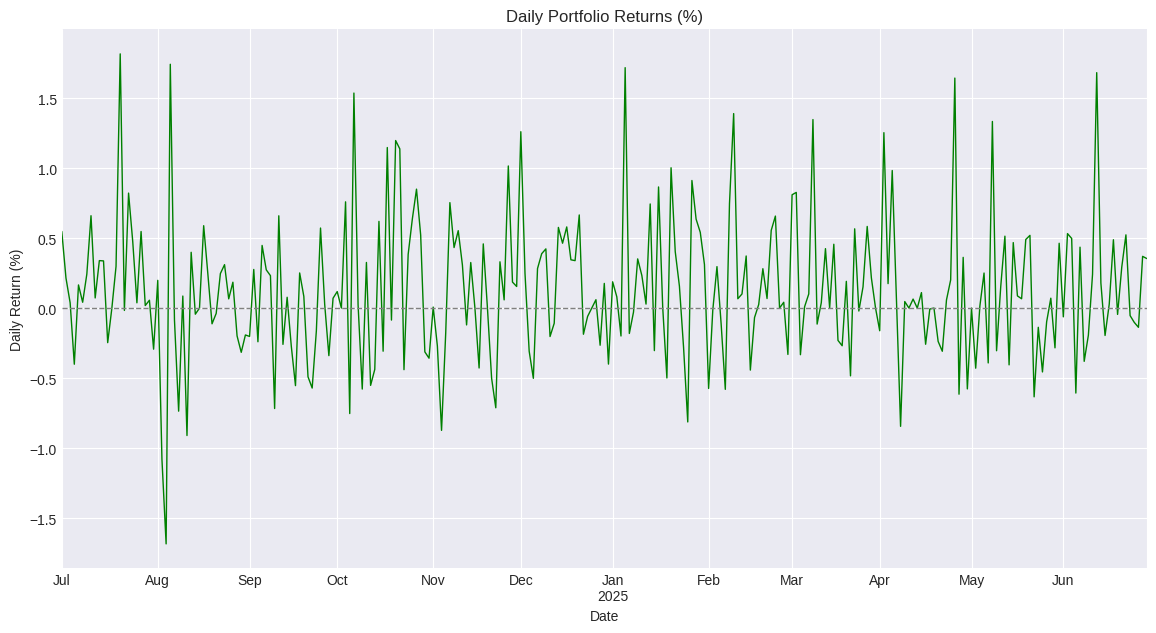

In [ ]:
START_DATE = '2024-07-01'
END_DATE = '2025-06-30'
INITIAL_CAPITAL = 100000

trades_df, portfolio_log_df = run_full_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    initial_capital=INITIAL_CAPITAL,
    all_data=strategy_dataframes
)

if not portfolio_log_df.empty:
    daily_returns_graph(trades_df, portfolio_log_df, INITIAL_CAPITAL, all_data=strategy_dataframes)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


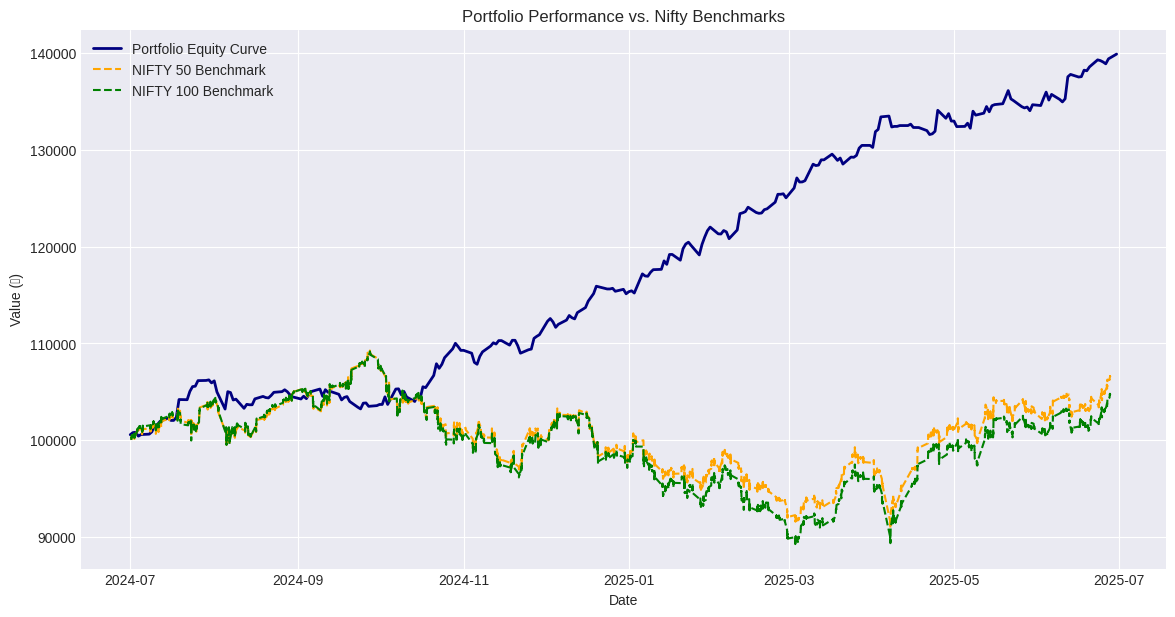

In [ ]:
# Ensure the necessary dataframes exist
if 'portfolio_log_df' not in locals() or portfolio_log_df.empty:
    print("Portfolio log data not available. Please run the backtest first.")
elif 'nifty' not in locals() or 'NIFTY 50' not in nifty or 'NIFTY 100' not in nifty:
    print("Nifty 50 or Nifty 100 data not available. Please ensure data loading was successful.")
else:
    # Get the portfolio value series, excluding the initial capital entry for
    portfolio_values = portfolio_log_df.iloc[1:]['portfolio_value']

    # Get the Nifty 50 and Nifty 100 dataframes
    nifty_50_df = nifty['NIFTY 50'].copy()
    nifty_100_df = nifty['NIFTY 100'].copy()


    date_column_name = 'date'
    nifty_50_df[date_column_name] = pd.to_datetime(nifty_50_df[date_column_name])
    nifty_50_df.set_index(date_column_name, inplace=True)

    nifty_100_df[date_column_name] = pd.to_datetime(nifty_100_df[date_column_name])
    nifty_100_df.set_index(date_column_name, inplace=True)

    # Filter Nifty data to match the backtest period
    start_date = portfolio_values.index[0] # Start from the first trading day of the backtest
    end_date = portfolio_values.index[-1]   # End at the last trading day of the backtest

    nifty_50_benchmark = nifty_50_df.loc[start_date:end_date]['close']
    nifty_100_benchmark = nifty_100_df.loc[start_date:end_date]['close']

    # Normalize the benchmarks to start at the same value as the initial portfolio capital
    nifty_50_start_price = nifty_50_benchmark.iloc[0] if not nifty_50_benchmark.empty else None
    nifty_100_start_price = nifty_100_benchmark.iloc[0] if not nifty_100_benchmark.empty else None

    if nifty_50_start_price is not None and nifty_100_start_price is not None:
        initial_benchmark_value = INITIAL_CAPITAL if 'INITIAL_CAPITAL' in locals() else 100000

        nifty_50_normalized = (nifty_50_benchmark / nifty_50_start_price) * initial_benchmark_value
        nifty_100_normalized = (nifty_100_benchmark / nifty_100_start_price) * initial_benchmark_value

        # Plotting
        plt.style.use('seaborn-v0_8-darkgrid')
        plt.figure(figsize=(14, 7))

        plt.plot(portfolio_values.index, portfolio_values, label='Portfolio Equity Curve', color='navy', linewidth=2)
        plt.plot(nifty_50_normalized.index, nifty_50_normalized, label='NIFTY 50 Benchmark', color='orange', linestyle='--')
        plt.plot(nifty_100_normalized.index, nifty_100_normalized, label='NIFTY 100 Benchmark', color='green', linestyle='--')

        plt.title('Portfolio Performance vs. Nifty Benchmarks')
        plt.xlabel('Date')
        plt.ylabel("Value (₹)")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Could not normalize benchmark data. Ensure Nifty data is available for the backtest period.")

In [ ]:
# Analyze trade exit reasons
if 'trades_df' in locals() and not trades_df.empty:
    print("Trade Exit Reason Analysis:")
    exit_reason_counts = trades_df['exit_reason'].value_counts()
    display(exit_reason_counts)


else:
    print("Trade data not available. Please run the backtest first.")

Trade Exit Reason Analysis:


,count
exit_reason,
Signal,4486
Force Close,1482
Stop Loss,783
Take Profit,49
